# Equilibrium Propagation Model — MemVal Benchmarks

This notebook evaluates the **Equilibrium Propagation (EP) Sequence Network** and the **Dentate Gyrus Enhanced EqProp (DGEqProp)** on the
same benchmarks as `demo.ipynb`:

1. **T-Maze Pattern Completion**
2. **Spatial Sequence Pattern Completion**
3. **Sequence Disambiguation**
4. **Object Arena / Novelty Benchmarks (NOR/OLM)**


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from memval.generators.t_maze import TMazeGenerator
from memval.generators.spatial import SpatialSequenceGenerator
from memval.generators.object_arena import ObjectArenaGenerator
from memval.models.baselines import EqPropSequenceNetwork, DGEqPropSequenceNetwork
from memval.benchmarks import PatternCompletionBenchmark
from memval.benchmarks.novelty import NoveltyBenchmark

sns.set_theme(style='darkgrid')

## 1. T-Maze Pattern Completion
Compare standard EP to DGEqProp on evaluating a sharp turn.

EP T-Maze MSE: {'pattern_completion_mse': 0.0810490343919425}
DGEqProp T-Maze MSE: {'pattern_completion_mse': 0.13783006691726374}


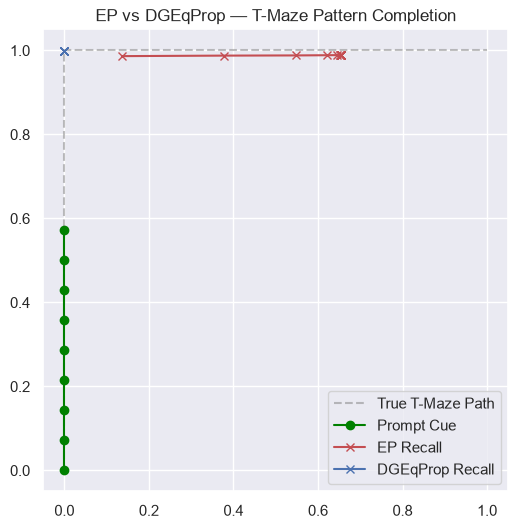

In [2]:
n_seqs = 1
seq_len = 30
tmaze_gen = TMazeGenerator(seed=42)
tmaze_trajectories = tmaze_gen.generate(
    n_sequences=n_seqs, sequence_length=seq_len, turn_direction='right'
)
tmaze_seq = tmaze_trajectories[0]

model_ep = EqPropSequenceNetwork(n_features=2, n_hidden=64, learning_rate=0.05, beta=0.5, seed=42)
model_ep.fit_sequence(tmaze_seq)

model_dgep = DGEqPropSequenceNetwork(n_features=2, n_dg=1000, n_hidden=128, sparsity=0.05, learning_rate=0.05, beta=0.5, seed=42, n_epochs=300)
model_dgep.fit_sequence(tmaze_seq)

benchmark = PatternCompletionBenchmark(metric='mse')
res_ep = benchmark.evaluate(model_ep, tmaze_trajectories, prompt_fraction=0.3)
res_dgep = benchmark.evaluate(model_dgep, tmaze_trajectories, prompt_fraction=0.3)
print('EP T-Maze MSE:', res_ep)
print('DGEqProp T-Maze MSE:', res_dgep)

prompt_len = int(seq_len * 0.3)
prompt = tmaze_seq[:prompt_len]
model_ep.reset_context()
rec_ep = model_ep.recall(prompt, length=seq_len - prompt_len)
model_dgep.reset_context()
rec_dgep = model_dgep.recall(prompt, length=seq_len - prompt_len)

plt.figure(figsize=(6, 6))
plt.plot(tmaze_seq[:, 0], tmaze_seq[:, 1], '--', color='gray', alpha=0.5, label='True T-Maze Path')
plt.plot(prompt[:, 0], prompt[:, 1], '-o', color='green', label='Prompt Cue')
plt.plot(rec_ep[:, 0], rec_ep[:, 1], '-xr', label='EP Recall')
plt.plot(rec_dgep[:, 0], rec_dgep[:, 1], '-xb', label='DGEqProp Recall')
plt.title('EP vs DGEqProp — T-Maze Pattern Completion')
plt.legend()
plt.show()

## 2. Spatial Sequence Pattern Completion
Random-walk trajectory with momentum.

In [3]:
gen = SpatialSequenceGenerator(n_dimensions=2, seed=42)
trajectories = gen.generate(n_sequences=1, sequence_length=50, step_size=0.1, momentum=0.9)
true_seq = trajectories[0]

m_ep = EqPropSequenceNetwork(n_features=2, seed=42)
m_ep.fit_sequence(true_seq)
m_dgep = DGEqPropSequenceNetwork(n_features=2, seed=42)
m_dgep.fit_sequence(true_seq)

bench2 = PatternCompletionBenchmark(metric='mse')
print('EP Spatial MSE:', bench2.evaluate(m_ep, trajectories, prompt_fraction=0.3))
print('DGEqProp Spatial MSE:', bench2.evaluate(m_dgep, trajectories, prompt_fraction=0.3))


EP Spatial MSE: {'pattern_completion_mse': 0.6436432216125172}
DGEqProp Spatial MSE: {'pattern_completion_mse': 0.005787008598172695}


## 3. Sequence Disambiguation Benchmark
Two crossing paths. The DGEqProp model shines here as it separates overlapping inputs based on context phase.

In [ ]:
seq_A_x = np.linspace(-1, 1, 30)
seq_A_y = np.linspace(1, -1, 30)
seq_A = np.column_stack([seq_A_x, seq_A_y])

seq_B_x = np.linspace(-1, 1, 30)
seq_B_y = np.linspace(-1, 1, 30)
seq_B = np.column_stack([seq_B_x, seq_B_y])

m_ep3 = EqPropSequenceNetwork(n_features=2, seed=42)
m_dgep3 = DGEqPropSequenceNetwork(n_features=2, seed=42)

# DisambiguationBenchmark was removed 2026-09-03: it was never wired into
# a pipeline and the shipped disambiguation section is
# benchmarks/spatial_disambiguation.py. Fit both crossing routes directly
# and score the post-crossing suffix inline.
def disamb_suffix_mse(m, ol_start=15):
    m.reset_context()
    m.fit_sequence(seq_A)
    m.fit_sequence(seq_B)
    out = {}
    for tag, seq in (('A', seq_A), ('B', seq_B)):
        m.reset_context()
        rec = m.recall(seq[:ol_start], length=len(seq) - ol_start)
        out[tag] = float(np.mean((np.asarray(rec) - seq[ol_start:]) ** 2))
    return out

print('EP suffix MSE through the crossing:', disamb_suffix_mse(m_ep3))
print('DGEqProp suffix MSE through the crossing:', disamb_suffix_mse(m_dgep3))

## 4. Object Arena and Novelty Benchmarks
Object-based assays: Novel Object Recognition (NOR) and Object Location Memory (OLM).

In [ ]:
arena_gen = ObjectArenaGenerator(n_objects=3, n_locations=3, seed=42)
familiar_seqs = arena_gen.generate(n_sequences=1, sequence_length=50, object_mapping=[0, 1, 2], interaction_radius=0.15)
test_seqs_olm = arena_gen.generate(n_sequences=1, sequence_length=50, object_mapping=[0, 2, 2], interaction_radius=0.15)
test_seqs_control = arena_gen.generate(n_sequences=1, sequence_length=50, object_mapping=[0, 1, 2], interaction_radius=0.15)

m_ep4 = EqPropSequenceNetwork(n_features=5, seed=42)
m_dgep4 = DGEqPropSequenceNetwork(n_features=5, seed=42)

bench4 = NoveltyBenchmark(metric='mse')
print('EP Control (Familiar) Error Spike:', bench4.evaluate(m_ep4, familiar_seqs, test_seqs_control))
print('EP OLM (Displacement) Error Spike:', bench4.evaluate(m_ep4, familiar_seqs, test_seqs_olm))
print('DGEqProp Control (Familiar) Error Spike:', bench4.evaluate(m_dgep4, familiar_seqs, test_seqs_control))
print('DGEqProp OLM (Displacement) Error Spike:', bench4.evaluate(m_dgep4, familiar_seqs, test_seqs_olm))